# Customer Appointment Data Cleaning

## Project Overview
The objective of this project is to demonstrate professional data cleaning techniques by transforming a raw, real-world healthcare dataset into a clean, consistent, and analysis-ready dataset.

Data cleaning is a critical step in the data analysis process because the quality of insights depends on the quality of the underlying data. Poor-quality data can lead to inaccurate analyses, misleading conclusions, and poor decision-making.

## Objectives

The objectives of this project are to:

- Inspect the dataset and assess its overall quality.
- Identify missing values, duplicate records, and inconsistent data.
- Handle missing values using appropriate techniques.
- Remove duplicate records where necessary.
- Standardize inconsistent formatting.
- Detect and treat outliers in numerical variables.
- Correct inappropriate data types.
- Compare the dataset before and after cleaning.
- Export the cleaned dataset for future analytical tasks.

In [3]:
import pandas as pd
df = pd.read_csv("C:/Users/USER/Documents/OIBSIP/DataAnalytics-L1-DataCleaning/KaggleV2-May-2016.csv")

In [5]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [9]:
df.shape

(110527, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [13]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [17]:
df.describe(include='all')

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
count,1.105270e+05,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527
unique,NaN,NaN,2,103549,27,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,NaN,JARDIM CAMBURI,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,71840,24,4692,NaN,7717,NaN,NaN,NaN,NaN,NaN,NaN,88208
mean,1.474963e+14,5.675305e+06,NaN,NaN,NaN,37.088874,NaN,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,NaN
std,2.560949e+14,7.129575e+04,NaN,NaN,NaN,23.110205,NaN,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,NaN
min,3.921784e+04,5.030230e+06,NaN,NaN,NaN,-1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,4.172614e+12,5.640286e+06,NaN,NaN,NaN,18.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,3.173184e+13,5.680573e+06,NaN,NaN,NaN,37.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,9.439172e+13,5.725524e+06,NaN,NaN,NaN,55.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN


##  Data Quality Assessment

A preliminary assessment of the dataset was conducted to evaluate its overall quality before cleaning.

### Summary of Findings

- The dataset contains **110,527 rows** and **14 columns**.
- No missing values were found in any column.
- No duplicate records were identified.
- However, several data quality issues were observed that require cleaning before analysis.

### Identified Issues

- `ScheduledDay` and `AppointmentDay` are stored as **object** data types instead of **datetime**.
- `PatientId` is stored as a **float**, even though it represents a unique identifier.
- The `Age` column contains an invalid minimum value of **-1**, which is not a valid age.
- Several categorical variables require validation to ensure their values are consistent.

In [20]:
print(df['Gender'].unique())

print(df['No-show'].unique())

print(df['Handcap'].unique())

['F' 'M']
['No' 'Yes']
[0 1 2 3 4]


In [24]:
# Remove rows where Age is less than 0
df = df[df['Age'] >= 0

In [28]:
# Convert PatientId to integer
df['PatientId'] = df['PatientId'].astype('int64')

# Convert date columns to datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

## Data Type Correction

Some columns were stored using inappropriate data types for analysis.

The following corrections were made:

- Converted **PatientId** from `float64` to `int64` to remove unnecessary decimal values.
- Converted **ScheduledDay** from `object` to `datetime`.
- Converted **AppointmentDay** from `object` to `datetime`.

These changes improve data consistency and make the dataset more suitable for analysis.

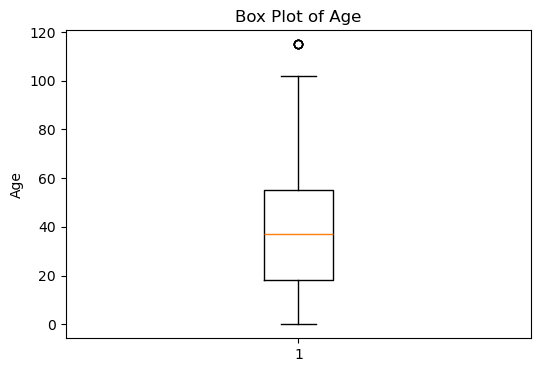

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

In [33]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -37.5
Upper Bound: 110.5


In [35]:
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

print(outliers.shape)
outliers.head()

(5, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
63912,31963211613981,5700278,F,2016-05-16 09:17:44+00:00,2016-05-19 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,Yes
63915,31963211613981,5700279,F,2016-05-16 09:17:44+00:00,2016-05-19 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,Yes
68127,31963211613981,5562812,F,2016-04-08 14:29:17+00:00,2016-05-16 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,Yes
76284,31963211613981,5744037,F,2016-05-30 09:44:51+00:00,2016-05-30 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,No
97666,748234579244724,5717451,F,2016-05-19 07:57:56+00:00,2016-06-03 00:00:00+00:00,115,SÃO JOSÉ,0,1,0,0,0,1,No


### Outlier Detection

The IQR (Interquartile Range) method was used to identify potential outliers in the **Age** column.

- Lower Bound: **-37.5**
- Upper Bound: **110.5**

Five records were identified as outliers, all with an age of **115 years**. Further inspection showed that these records belonged to only two patients with multiple appointments.

Although these values were identified as statistical outliers, they were **retained** because an age of 115 is rare but still biologically possible. There was no evidence to suggest these records resulted from data entry errors.

Therefore, no outliers were removed from the dataset.

In [38]:
summary = pd.DataFrame({
    'Metric': [
        'Number of Rows',
        'Number of Columns',
        'Missing Values',
        'Duplicate Rows',
        'Invalid Age Records',
        'Incorrect Data Types'
    ],
    'Before Cleaning': [
        110527,
        14,
        0,
        0,
        1,
        3
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df['Age'] < 0).sum(),
        0
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Number of Rows,110527,110526
1,Number of Columns,14,14
2,Missing Values,0,0
3,Duplicate Rows,0,0
4,Invalid Age Records,1,0
5,Incorrect Data Types,3,0


## Before vs After Data Quality Summary

The table below compares the dataset before and after the data cleaning process.

Overall, the dataset required only minor cleaning. No missing values or duplicate records were found. The cleaning process focused on correcting data types and removing the single invalid age record while retaining valid but rare observations.

These improvements ensure that the dataset is accurate, consistent, and ready for further analysis.

In [41]:
df.to_csv('Medical_Appointment_Cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Exporting the Cleaned Dataset

After completing the data cleaning process, the cleaned dataset was exported as a new CSV file named **Medical_Appointment_Cleaned.csv**. This version of the dataset is free from identified data quality issues and is ready for exploratory data analysis, visualization, or predictive modeling.

## Conclusion

This project demonstrated a structured approach to cleaning a real-world healthcare dataset using Python and pandas.

The dataset was examined for missing values, duplicate records, incorrect data types, invalid values, and outliers. Appropriate cleaning techniques were applied where necessary, including correcting data types and removing an invalid age record. Statistical outliers in the Age column were assessed and retained because they represented plausible observations rather than data entry errors.

The final cleaned dataset is now suitable for reliable analysis and can support future data visualization, statistical analysis, or machine learning applications.